In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [8]:
df = pd.read_csv('traffic.csv')
df = pd.DataFrame(df)
df.head()

,date,time,traffic_volume,congestion_level,accidents,location
0,2025-04-25,08:00,396,High,0,Johar Town
1,2025-04-25,13:00,463,High,3,Ferozepur Road
2,2025-04-25,18:00,319,High,0,Johar Town
3,2025-04-26,08:00,518,Low,3,Ferozepur Road
4,2025-04-26,13:00,179,Low,0,Ferozepur Road


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              183 non-null    object
 1   time              183 non-null    object
 2   traffic_volume    183 non-null    int64 
 3   congestion_level  183 non-null    object
 4   accidents         183 non-null    int64 
 5   location          183 non-null    object
dtypes: int64(2), object(4)
memory usage: 8.7+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
traffic_volume,183.0,466.180328,212.808394,103.0,292.5,483.0,664.5,799.0
accidents,183.0,1.442623,1.126961,0.0,0.0,1.0,2.0,3.0


In [5]:
df.isnull().sum()

date                0
time                0
traffic_volume      0
congestion_level    0
accidents           0
location            0
dtype: int64

# Handle Missing Data

In [12]:

categorical_columns = [
    'Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity',
    'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition', 'Driver_Alcohol'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    
df['Traffic_Density'] = df['Traffic_Density'].fillna(df['Traffic_Density'].median())
df['Number_of_Vehicles'] = df['Number_of_Vehicles'].fillna(df['Number_of_Vehicles'].median())
df['Driver_Age'] = df['Driver_Age'].fillna(df['Driver_Age'].mean())

df['Speed_Limit'] = df.groupby('Road_Type')['Speed_Limit'].transform(
    lambda x: x.fillna(x.mean())
)

df['Accident'] = df['Accident'].fillna(df['Accident'].mode()[0])

df['Driver_Experience'] = df['Driver_Experience'].fillna(df['Driver_Experience'].median())
print(df.isnull().sum())


KeyError: 'Weather'

# Feature Engineering

In [7]:
# 1. Is it Night?
df['Is_Night'] = df['Time_of_Day'].apply(lambda x: 1 if x in ['Night', 'Late Night'] else 0)
print(df[['Time_of_Day', 'Is_Night']].head(10))

KeyError: 'Time_of_Day'

In [ ]:
# 2. Driver Age Group
age_bins = [18, 30, 45, 60, 70]
age_labels = ['Young', 'Adult', 'Middle', 'Senior']
df['Driver_Age_Group'] = pd.cut(df['Driver_Age'], bins=age_bins, labels=age_labels)
df['Driver_Age_Group'] = df['Driver_Age_Group'].fillna(df['Driver_Age_Group'].mode()[0])
print(df[['Driver_Age', 'Driver_Age_Group']].head(), "\n")

   Driver_Age Driver_Age_Group
0        51.0           Middle
1        49.0           Middle
2        54.0           Middle
3        34.0            Adult
4        62.0           Senior 



In [ ]:
# 3. Driver Experience Level
df['Experience_Level'] = pd.cut(df['Driver_Experience'],
                                bins=[0, 5, 15, 30],
                                labels=['Low', 'Medium', 'High'])
df['Experience_Level'] = df['Experience_Level'].fillna(df['Experience_Level'].mode()[0])
print(df[['Driver_Experience', 'Experience_Level']].head(), "\n")

   Driver_Experience Experience_Level
0               48.0             High
1               43.0             High
2               52.0             High
3               31.0             High
4               55.0             High 



In [ ]:
# 4. Risky Weather
df['Is_Risky_Weather'] = df['Weather'].apply(lambda x: 1 if x in ['Rain', 'Fog', 'Storm', 'Snow'] else 0)
print(df[['Weather', 'Is_Risky_Weather']].head(), "\n")

  Weather  Is_Risky_Weather
0   Rainy                 0
1   Clear                 0
2   Rainy                 0
3   Clear                 0
4   Rainy                 0 



In [ ]:
# 5. Risky Road Condition
df['Is_Risky_Road'] = df['Road_Condition'].apply(lambda x: 1 if x in ['Wet', 'Icy', 'Snowy'] else 0)
print(df[['Road_Condition', 'Is_Risky_Road']].head(), "\n")

       Road_Condition  Is_Risky_Road
0                 Wet              1
1                 Wet              1
2                 Icy              1
3  Under Construction              0
4                 Dry              0 



In [ ]:
# 6. Road Light Condition – Binary
df['Is_Dark'] = df['Road_Light_Condition'].apply(lambda x: 1 if x in ['Dark', 'Poor Lighting'] else 0)
print(df[['Road_Light_Condition', 'Is_Dark']].head(), "\n")

  Road_Light_Condition  Is_Dark
0     Artificial Light        0
1     Artificial Light        0
2     Artificial Light        0
3             Daylight        0
4     Artificial Light        0 



In [ ]:
# 8. Risk Score – Composite Feature
df['Risk_Score'] = (
    df['Traffic_Density'] * 0.4 +
    df['Is_Night'] * 0.2 +
    df['Is_Risky_Weather'] * 0.2 +
    df['Is_Risky_Road'] * 0.2
)
print(df[['Traffic_Density', 'Is_Night', 'Is_Risky_Weather', 'Is_Risky_Road', 'Risk_Score']].head(), "\n")

   Traffic_Density  Is_Night  Is_Risky_Weather  Is_Risky_Road  Risk_Score
0              1.0         0                 0              1         0.6
1              1.0         1                 0              1         0.8
2              1.0         0                 0              1         0.6
3              2.0         0                 0              0         0.8
4              1.0         0                 0              0         0.4 



In [ ]:
from sklearn.preprocessing import LabelEncoder
label_cols = ['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity',
              'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition',
              'Driver_Age_Group', 'Experience_Level']

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head(10)

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,...,Driver_Experience,Road_Light_Condition,Accident,Is_Night,Driver_Age_Group,Experience_Level,Is_Risky_Weather,Is_Risky_Road,Is_Dark,Risk_Score
0,2,0,2,1.0,100.0,5.0,0.0,1,3,1,...,48.0,0,0.0,0,1,0,0,1,0,0.6
1,0,3,3,1.0,120.0,3.0,0.0,2,3,3,...,43.0,0,0.0,1,1,0,0,1,0,0.8
2,2,1,1,1.0,60.0,4.0,0.0,1,1,1,...,52.0,0,0.0,0,1,0,0,1,0,0.6
3,0,0,0,2.0,60.0,3.0,0.0,1,2,0,...,31.0,1,0.0,0,0,0,0,0,0,0.8
4,2,1,2,1.0,195.0,11.0,0.0,1,0,1,...,55.0,0,1.0,0,2,0,0,0,0,0.4
5,0,3,3,0.0,120.0,3.0,0.0,2,0,3,...,43.0,0,0.0,1,1,0,0,0,0,0.2
6,1,1,0,0.0,60.0,4.0,0.0,1,0,3,...,26.0,1,1.0,0,3,0,0,0,0,0.0
7,2,0,0,0.0,60.0,4.0,0.0,1,0,1,...,22.0,0,1.0,0,3,0,0,0,0,0.0
8,4,1,2,1.0,60.0,2.0,0.0,0,1,1,...,29.0,0,0.0,0,0,0,0,1,0,0.6
9,2,0,0,2.0,30.0,2.0,0.0,1,0,3,...,48.0,0,0.0,0,1,0,0,0,0,0.8


# Exploratory Data Analysis

# Line plot 
     Number of Accidents by Weather Type

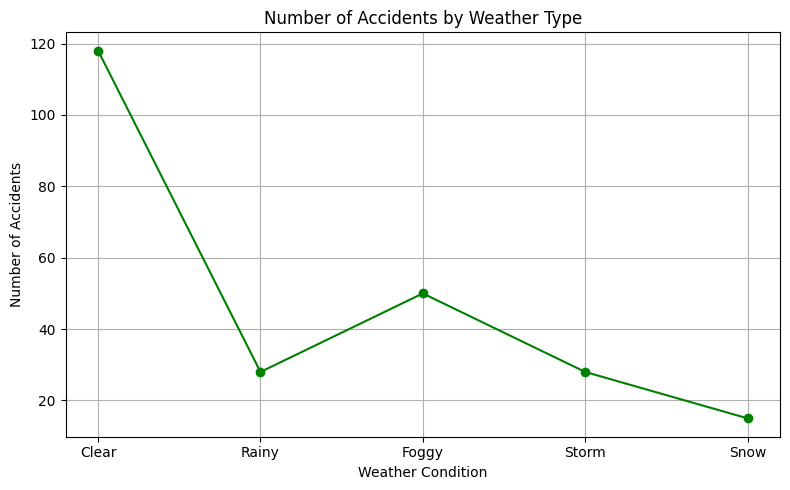

In [ ]:
weather_accidents = df.groupby('Weather')['Accident'].sum().reset_index()

weather_accidents = weather_accidents.sort_values(by='Weather')
weather_labels = {0: 'Clear', 1: 'Rainy', 2: 'Foggy', 3: 'Storm', 4: 'Snow'}
weather_accidents['Weather_Label'] = weather_accidents['Weather'].map(weather_labels)

plt.figure(figsize=(8, 5))
plt.plot(weather_accidents['Weather_Label'], weather_accidents['Accident'], marker='o', linestyle='-', color='green')
plt.title('Number of Accidents by Weather Type')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.tight_layout()
plt.show()





From the line plot, we observed that 
Clear weather has the highest number of accidents compared to other weather types (Rainy, Foggy, etc.).

#  Box plot
       Vehicles on Road by Weather Condition

In [ ]:
# Mapping weather codes to labels
weather_labels = {
    0: 'Clear',
    1: 'Rainy',
    2: 'Foggy',
    3: 'Storm',
    4: 'Snow'
}

# Add new labeled column
df['Weather_Label'] = df['Weather'].map(weather_labels)


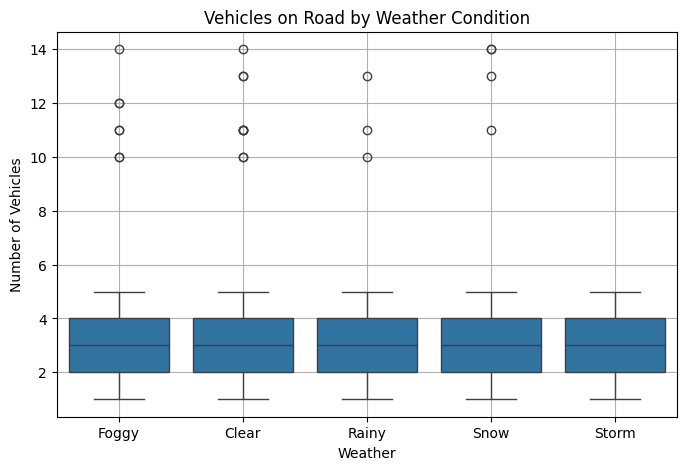

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weather_Label', y='Number_of_Vehicles', data=df)
plt.title('Vehicles on Road by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Number of Vehicles')
plt.grid(True)
plt.show()


The boxplot shows that more vehicles are on the road in clear weather.                                                                 
This suggests higher traffic volume, which naturally increases accident likelihood.


     Speed Limit versus Weather

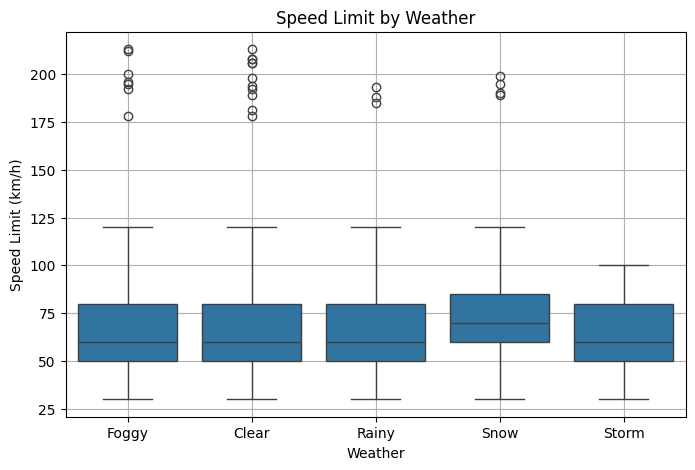

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weather_Label', y='Speed_Limit', data=df)
plt.title('Speed Limit by Weather')
plt.xlabel('Weather')
plt.ylabel('Speed Limit (km/h)')
plt.grid(True)
plt.show()


Speed limits are generally higher or people tend to drive faster in clear weather.


Higher speeds often lead to more severe or frequent accidents, especially with congestion.

# Count plot
       Accidents by Time of Day

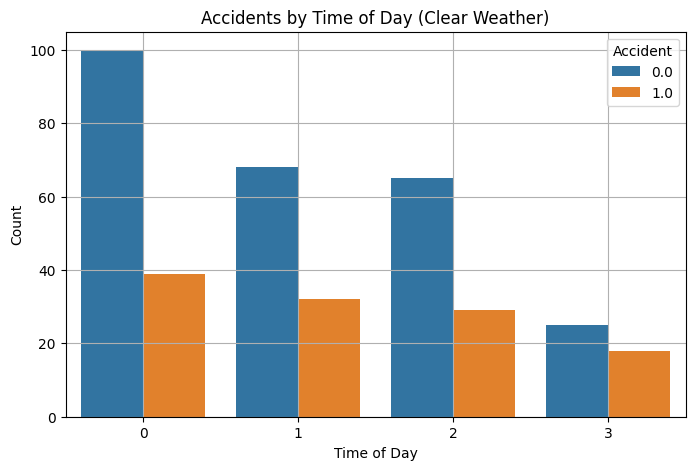

In [ ]:
clear_df = df[df['Weather_Label'] == 'Clear']

plt.figure(figsize=(8,5))
sns.countplot(x='Time_of_Day', hue='Accident', data=clear_df)
plt.title('Accidents by Time of Day (Clear Weather)')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.legend(title='Accident')
plt.grid(True)
plt.show()


Most accidents during clear weather occur during peak hours (morning/evening), as seen in the countplot.

These are times when traffic density is high, further increasing accident risk.

  
       Traffic Density by Weather

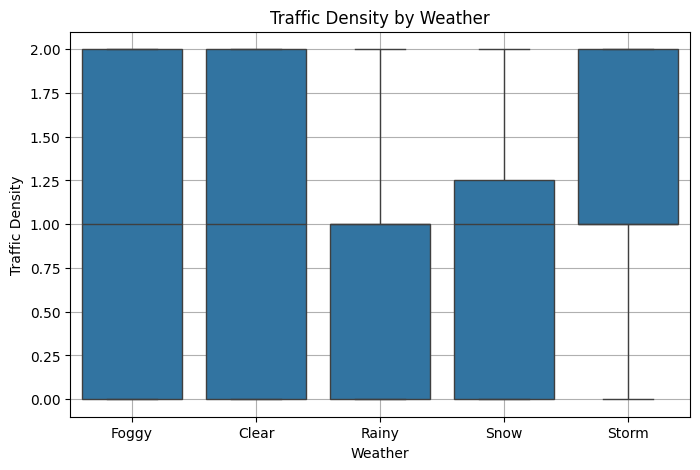

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weather_Label', y='Traffic_Density', data=df)
plt.title('Traffic Density by Weather')
plt.xlabel('Weather')
plt.ylabel('Traffic Density')
plt.grid(True)
plt.show()


Clear weather has higher traffic density, as shown in the boxplot.

More vehicles + higher density → higher probability of collisions.


     Drivers Experience

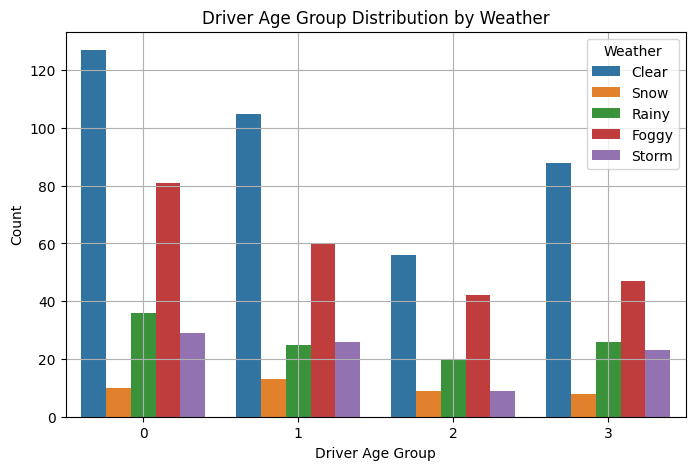

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Driver_Age_Group', hue='Weather_Label', data=df)
plt.title('Driver Age Group Distribution by Weather')
plt.xlabel('Driver Age Group')
plt.ylabel('Count')
plt.legend(title='Weather')
plt.grid(True)
plt.show()


If younger or less experienced drivers dominate during clear conditions, that could also increase accident chances (from age/experience plots).

# Heat Map
      Between accidents and features

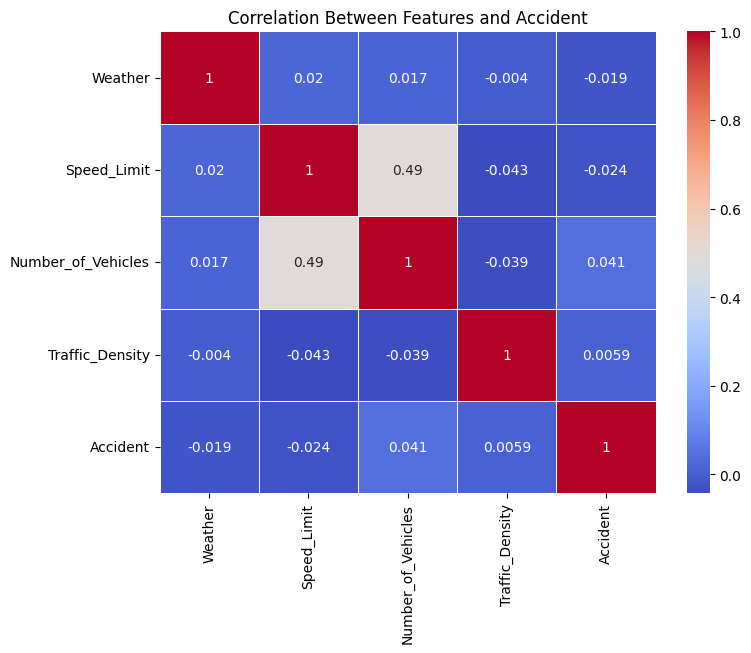

In [ ]:
features = ['Weather', 'Speed_Limit', 'Number_of_Vehicles', 'Traffic_Density', 'Accident']
corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features and Accident')
plt.show()


Accident frequency is more strongly correlated with traffic density and number of vehicles than with weather.

This suggests that Clear weather doesn't directly cause more accidents, but creates conditions (more traffic, higher speeds) that do.

# Pairwise comparison

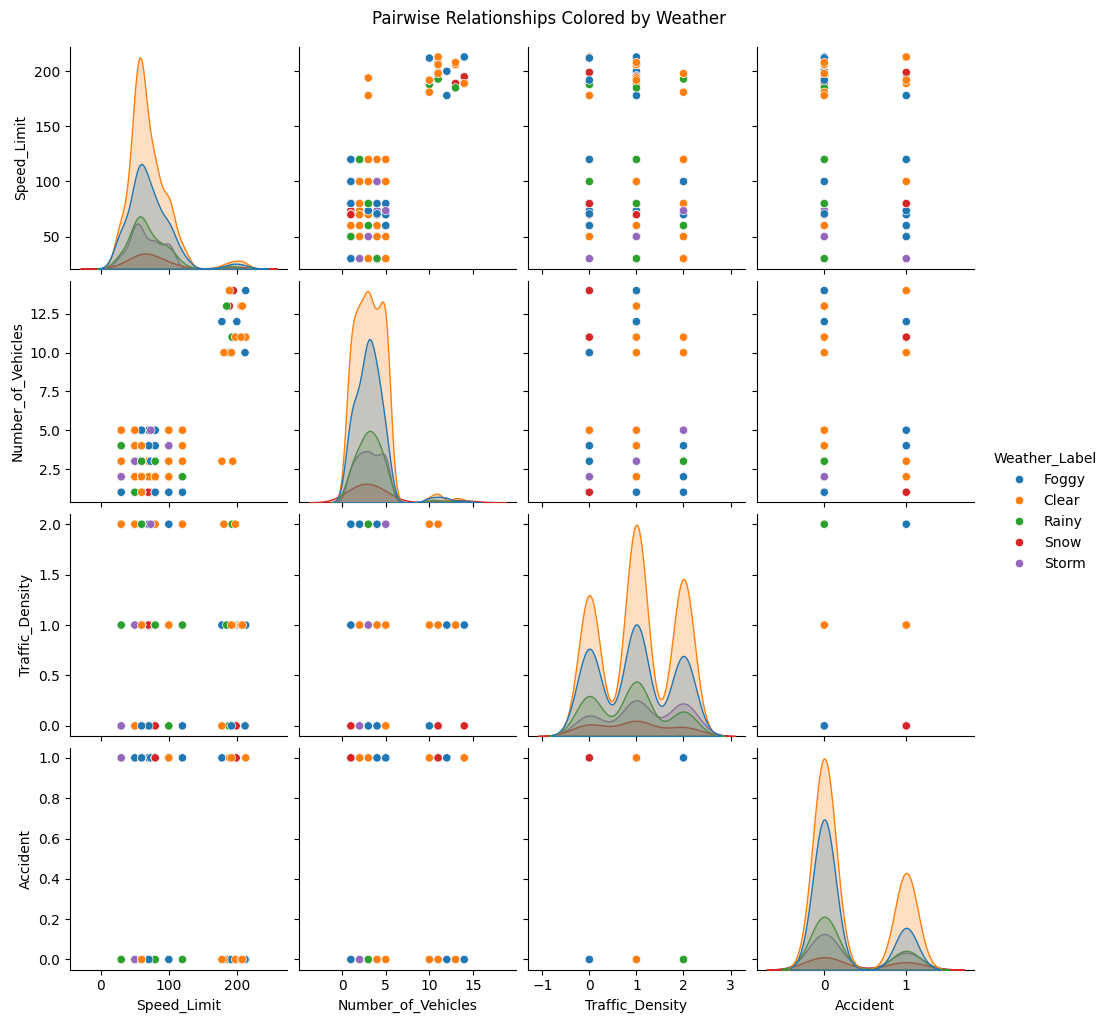

In [ ]:
sns.pairplot(df, hue='Weather_Label', vars=['Speed_Limit', 'Number_of_Vehicles', 'Traffic_Density', 'Accident'])
plt.suptitle('Pairwise Relationships Colored by Weather', y=1.02)
plt.show()


# Conclusion
        Clear weather leads to more accidents not because it's dangerous, but because it encourages more road usage, higher speeds, and denser traffic. These factors, not the weather itself, increase accident risk.

#  Model Training

#             Random Forest  Classifier

In [ ]:
y = df['Accident']
X = df.drop(columns=['Accident'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X[col] = label_enc.fit_transform(X[col])

In [ ]:
X = X.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7083333333333334

Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.97      0.82       117
         1.0       0.60      0.12      0.20        51

    accuracy                           0.71       168
   macro avg       0.66      0.54      0.51       168
weighted avg       0.68      0.71      0.63       168



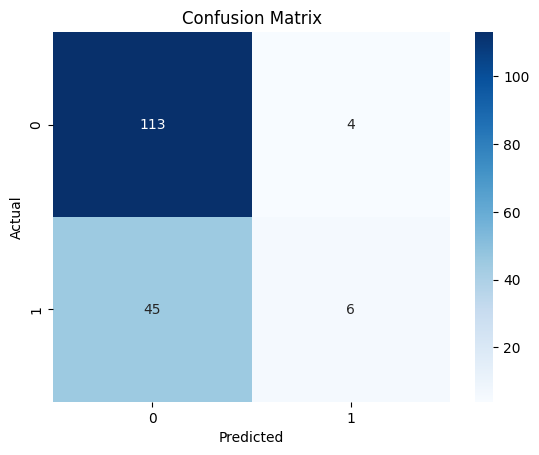

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

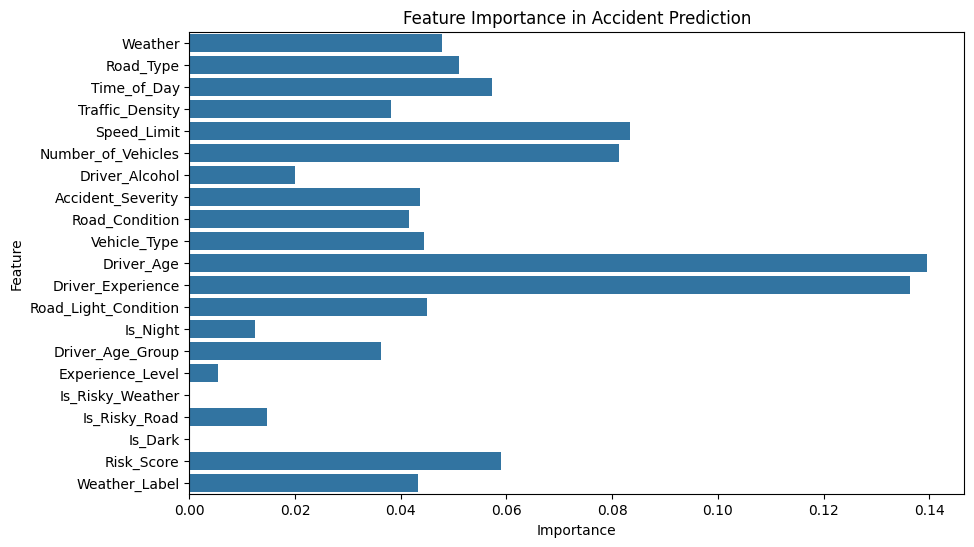

In [ ]:
feature_importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=features)
plt.title('Feature Importance in Accident Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Logistic  Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import matplotlib.pyplot as plt

In [ ]:
# 1. Train Logistic Regression with class balancing
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# 2. Make predictions
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

In [ ]:
# 3. Evaluation Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.53
Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.54      0.61       117
         1.0       0.33      0.51      0.40        51

    accuracy                           0.53       168
   macro avg       0.52      0.52      0.51       168
weighted avg       0.60      0.53      0.55       168



<Figure size 600x400 with 0 Axes>

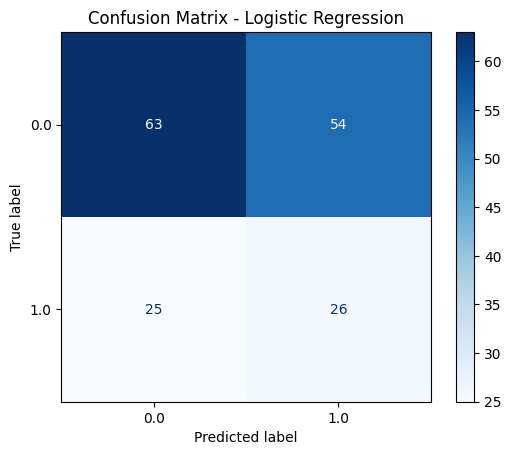

In [ ]:
# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
plt.figure(figsize=(6,4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

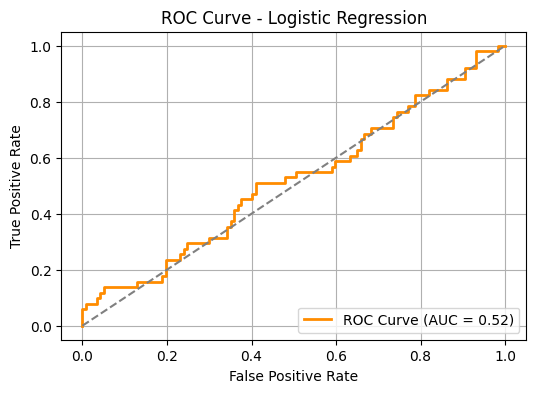

In [ ]:
# 5. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
